In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
root = '/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Documents/synth-data'

In [3]:
import json
import pandas as pd
from pathlib import Path
import re

def create_dataframe_from_results_json(spaces_folder):
    """
    Recursively search through spaces folder to find all results.json files
    and create a DataFrame with extracted information.
    
    Args:
        spaces_folder (str): Path to the spaces folder
        
    Returns:
        pd.DataFrame: DataFrame containing data from all results.json files
    """
    # Convert to Path object for easier handling
    spaces_path = Path(spaces_folder)
    
    # Find all results.json files recursively
    json_files = list(spaces_path.glob('**/results.json'))
    
    all_data = []
    
    for json_file in json_files:
        try:
            # Extract path components
            parts = json_file.parts
            
            # Find the index of 'spaces' in the path
            try:
                spaces_index = parts.index('spaces')
            except ValueError:
                # If 'spaces' not in path, use the first element
                spaces_index = 5
            
            # Extract region_function (assuming it's right after 'spaces')
            if spaces_index + 1 < len(parts):
                region_function = parts[spaces_index + 1]
            else:
                region_function = "unknown"
            
            # Split region and function (e.g., "R1-49" into "R1" and "49")
            match = re.match(r'([A-Za-z]+)(\d*)-(\d+)', region_function)
            if match:
                region = match.group(1) + match.group(2)  # R1
                function = match.group(3)                 # 49
            else:
                region = region_function
                function = region_function
            
            # Extract week (assuming it's the directory containing results.json)
            week = parts[-2]
            
            # Load JSON data
            with open(json_file, "r") as f:
                data = json.load(f)
            
            # If data is a dictionary, wrap it in a list
            if isinstance(data, dict):
                data = [data]
            
            # Create DataFrame from this file
            file_df = pd.json_normalize(data)
            
            # Add extracted columns
            file_df["region"] = region
            file_df["function"] = str(function)
            file_df["week"] = week
            file_df["file_path"] = str(json_file)
            
            all_data.append(file_df)
            
        except Exception as e:
            print(f"Error processing {json_file}: {e}")
    
    # Combine all dataframes
    if all_data:
        final_df = pd.concat(all_data, ignore_index=True)
        return final_df
    else:
        print("No valid results.json files found")
        return pd.DataFrame()

# Example usage
df = create_dataframe_from_results_json(f"{root}/spaces_dnn1_final_request_patterns")
df


,averageQueueTime,penaltyProportion,averageExecutionTime,averageComputerTime,averageWaitTime,endTime,region,function,week,file_path
0,2.284383,10.774929,0.002930,0.024008,0.0,1199.960429,R1,1437,2,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
1,1.678959,8.984440,0.001048,0.022125,0.0,1199.940818,R1,1437,0,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
2,1.804193,8.275311,0.001106,0.022184,0.0,1199.950990,R1,1437,3,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
3,1.473295,7.864338,0.002724,0.023802,0.0,1199.967254,R1,1437,1,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
4,1.318190,6.613689,0.001371,0.022449,0.0,1199.964427,R1,49,2,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
5,0.372158,1.626269,0.001424,0.022287,0.0,1199.947894,R1,49,0,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
6,0.648904,4.135374,0.003785,0.024863,0.0,1199.964625,R1,49,3,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
7,2.628731,12.766142,0.001048,0.022125,0.0,1199.962620,R1,49,1,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
8,1.240076,5.939696,0.003620,0.024698,0.0,1199.971237,R1,1412,2,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...
9,1.315262,6.015964,0.003424,0.024502,0.0,1199.991290,R1,1412,0,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...


Text(0.5, 0, 'Function')

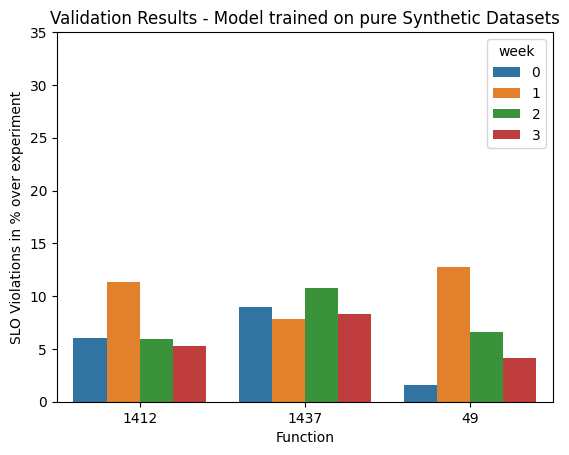

In [4]:
g = sns.barplot(x='function', y='penaltyProportion', hue='week', data=df.sort_values(by=['function', 'week']))
g.set_ylim(0,35)
g.set_title('Validation Results - Model trained on pure Synthetic Datasets')
g.set_ylabel('SLO Violations in % over experiment')
g.set_xlabel('Function')

In [22]:
df.groupby(['week'])['penaltyProportion'].describe()

,count,mean,std,min,25%,50%,75%,max
week,,,,,,,,
0,8.0,7.595706,2.899224,2.512219,6.559001,7.210815,10.008444,11.462729
1,8.0,9.250121,3.439146,4.976679,6.640910,9.124524,10.749642,15.973221
2,8.0,8.015208,2.417974,5.224361,5.957996,7.490962,10.390507,10.980285
3,8.0,8.674019,2.175886,6.064409,7.294752,7.624767,10.654248,11.809522


In [7]:
import pandas as pd
from pathlib import Path
import re

def calculate_statistics_from_system_events(spaces_folder):
    """
    Recursively search through spaces folder to find all system_events.csv files,
    read them as DataFrames, and calculate comprehensive statistics for 'count' and 'average_queue_length'.
    Also extracts region, function, and week from the file path.

    Args:
        spaces_folder (str): Path to the spaces folder

    Returns:
        pd.DataFrame: DataFrame containing statistics for each file with path information
    """
    # Convert to Path object for easier handling
    spaces_path = Path(spaces_folder)
    
    # Find all system_events.csv files recursively
    csv_files = list(spaces_path.glob('**/system_events.csv'))
    
    results = []
    
    for csv_file in csv_files:
        try:
            # Extract path components
            parts = csv_file.parts
            
            # Find the index of 'spaces' in the path
            try:
                spaces_index = parts.index('spaces')
            except ValueError:
                # If 'spaces' not in path, use the first element
                spaces_index = 5
            
            # Extract region_function (assuming it's right after 'spaces')
            if spaces_index + 1 < len(parts):
                region_function = parts[spaces_index + 1]
            else:
                region_function = "unknown"
            
            # Split region and function (e.g., "R1-49" into "R1" and "49")
            match = re.match(r'([A-Za-z]+)(\d*)-(\d+)', region_function)
            if match:
                region = match.group(1) + match.group(2)  # R1
                function = match.group(3)                 # 49
            else:
                region = region_function
                function = region_function
            
            # Extract week (assuming it's the directory containing system_events.csv)
            week = parts[-2]
            
            # Read the CSV file into a DataFrame
            df = pd.read_csv(csv_file)
            
            # Calculate statistics for count
            count_mean = df['count'].mean()
            count_min = df['count'].min()
            count_max = df['count'].max()
            count_std = df['count'].std()
            count_median = df['count'].median()
            
            # Calculate statistics for average_queue_length
            queue_mean = df['average_queue_length'].mean()
            queue_min = df['average_queue_length'].min()
            queue_max = df['average_queue_length'].max()
            queue_std = df['average_queue_length'].std()
            queue_median = df['average_queue_length'].median()
            
            # Append results
            results.append({
                'file_path': str(csv_file),
                'region': region,
                'function': function,
                'week': week,
                'count_mean': count_mean,
                'count_min': count_min,
                'count_max': count_max,
                'count_std': count_std,
                'count_median': count_median,
                'queue_mean': queue_mean,
                'queue_min': queue_min,
                'queue_max': queue_max,
                'queue_std': queue_std,
                'queue_median': queue_median
            })
        except Exception as e:
            print(f"Error processing {csv_file}: {e}")
    
    # Convert results to a DataFrame
    if results:
        final_df = pd.DataFrame(results)
        return final_df
    else:
        print("No valid system_events.csv files found")
        return pd.DataFrame()

# Example usage
system_events_df = calculate_statistics_from_system_events(f"{root}/spaces_dnn2_final_request_patterns")
system_events_df


,file_path,region,function,week,count_mean,count_min,count_max,count_std,count_median,queue_mean,queue_min,queue_max,queue_std,queue_median
0,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,1437,2,40.913580,33,48,3.966099,41.0,7.350225,0.0,198.687500,30.326851,0.173913
1,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,1437,0,38.024691,32,43,3.098287,39.0,6.020188,0.0,171.418605,25.454795,0.175000
2,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,1437,3,39.691358,32,48,3.686604,40.0,5.750024,0.0,172.595238,24.961018,0.128205
3,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,1437,1,42.913580,35,54,4.461495,42.0,5.985373,0.0,155.062500,23.404687,0.157895
4,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,49,2,57.000000,57,57,0.000000,57.0,1.921161,0.0,62.649123,8.305947,0.070175
5,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,49,0,54.839506,47,57,2.690059,56.0,1.575922,0.0,48.684211,6.449864,0.192982
6,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,49,3,55.753086,49,57,1.900861,57.0,1.851536,0.0,58.298246,7.689712,0.122807
7,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,49,1,53.925926,23,57,6.789289,57.0,8.392307,0.0,197.972222,35.131766,0.092593
8,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,1412,2,24.287500,20,34,3.077866,23.0,4.818199,0.0,181.478261,25.154770,0.173913
9,/mnt/d3589f7b-9dda-43cc-a71c-0fa8ecbdc3eb/Docu...,R1,1412,0,39.888889,31,50,4.555217,40.0,6.001430,0.0,189.472222,27.274797,0.184211


Text(0.5, 1.0, 'Resource Usage with model trained on Synthetic Data')

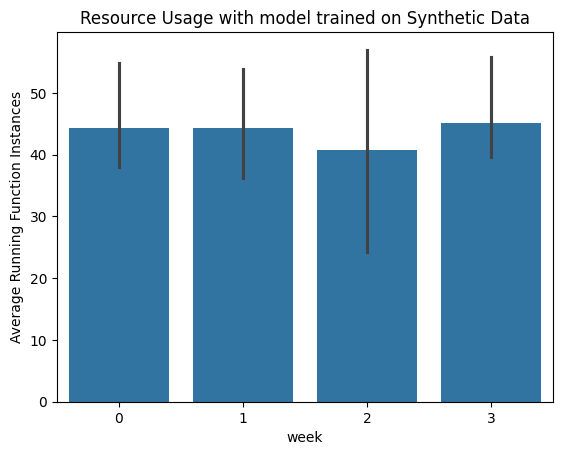

In [8]:
g = sns.barplot( y='count_mean', x='week', data=system_events_df.sort_values(by='week'))
g.set_ylabel("Average Running Function Instances")
g.set_title("Resource Usage with model trained on Synthetic Data")